# Adaptive Retrieval Gating — Progress Demo
### Variant 5: When to Retrieve? Gating Policies for Offline Medical QA

**Author:** Idea Khan | **Project:** qVault Variant 5 | **Date:** March 2026

---

This notebook demonstrates the **core concept** of adaptive retrieval gating on sample MIRAGE-style medical questions. It shows:

1. **Three gating mechanisms** (Token Entropy, Logit Margin, Verbalized Confidence)
2. **Risk stratification** of medical questions (Low / Medium / High clinical urgency)
3. **Gate decisions** — retrieve or skip? — and how they differ by question difficulty
4. **Policy comparison** across Always-Retrieve, Closed-Book, and Selective/Gated

> **Note:** This demo uses **simulated logit distributions** to illustrate the gating logic. The full implementation will use real logits from GGUF-quantized models via llama.cpp.

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from dataclasses import dataclass
from typing import Literal
import time
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
print("Environment ready.")

Environment ready.


## 1. Sample Medical Questions (MIRAGE-style)

These questions span the three clinical risk levels. In the full project, all 7,663 MIRAGE questions plus RAGCare-QA and acute-care sets will be tagged this way.

In [10]:
@dataclass
class MedicalQuestion:
    """A single evaluation question with risk metadata."""
    qid: str
    question: str
    choices: list
    correct: str
    risk_level: Literal["Low", "Medium", "High"]
    source: str  # which dataset it comes from
    category: str

# Sample questions representing the three risk tiers
SAMPLE_QUESTIONS = [
    # --- LOW RISK: Textbook recall, anatomy, basic science ---
    MedicalQuestion(
        qid="MIRAGE-L1",
        question="Which cranial nerve is responsible for innervation of the diaphragm?",
        choices=["A. Vagus nerve", "B. Phrenic nerve", "C. Accessory nerve", "D. Hypoglossal nerve"],
        correct="B",
        risk_level="Low",
        source="MMLU-Med (Anatomy)",
        category="Anatomy"
    ),
    MedicalQuestion(
        qid="MIRAGE-L2",
        question="What is the most abundant immunoglobulin in human serum?",
        choices=["A. IgA", "B. IgM", "C. IgG", "D. IgE"],
        correct="C",
        risk_level="Low",
        source="MMLU-Med (Immunology)",
        category="Basic Science"
    ),
    MedicalQuestion(
        qid="MIRAGE-L3",
        question="The citric acid cycle primarily takes place in which cellular compartment?",
        choices=["A. Cytoplasm", "B. Nucleus", "C. Mitochondrial matrix", "D. Endoplasmic reticulum"],
        correct="C",
        risk_level="Low",
        source="MMLU-Med (Biochemistry)",
        category="Basic Science"
    ),
    # --- MEDIUM RISK: Clinical reasoning, differential diagnosis ---
    MedicalQuestion(
        qid="MIRAGE-M1",
        question="A 55-year-old male presents with sudden-onset crushing chest pain radiating to the left arm, diaphoresis, and ST-segment elevation in leads II, III, and aVF. What is the most likely diagnosis?",
        choices=["A. Pulmonary embolism", "B. Inferior STEMI", "C. Aortic dissection", "D. Pericarditis"],
        correct="B",
        risk_level="Medium",
        source="MedQA-US",
        category="Cardiology"
    ),
    MedicalQuestion(
        qid="MIRAGE-M2",
        question="A patient with type 2 diabetes presents with an HbA1c of 9.2% on metformin monotherapy. According to current guidelines, what is the recommended next step?",
        choices=["A. Add a sulfonylurea", "B. Add a GLP-1 receptor agonist", "C. Switch to insulin", "D. Add an SGLT2 inhibitor"],
        correct="B",
        risk_level="Medium",
        source="RAGCare-QA (Endocrinology)",
        category="Endocrinology"
    ),
    MedicalQuestion(
        qid="MIRAGE-M3",
        question="A 30-year-old woman presents with fatigue, weight gain, and cold intolerance. TSH is elevated and free T4 is low. What is the most likely diagnosis?",
        choices=["A. Graves' disease", "B. Hashimoto's thyroiditis", "C. Subacute thyroiditis", "D. Thyroid carcinoma"],
        correct="B",
        risk_level="Medium",
        source="MedMCQA",
        category="Endocrinology"
    ),
    # --- HIGH RISK: Drug interactions, dosing, emergency protocols ---
    MedicalQuestion(
        qid="ACUTE-H1",
        question="A patient on warfarin is prescribed fluconazole for a fungal infection. What is the expected drug interaction and clinical concern?",
        choices=["A. Decreased warfarin effect", "B. Increased bleeding risk due to CYP2C9 inhibition", "C. No significant interaction", "D. Increased fluconazole toxicity"],
        correct="B",
        risk_level="High",
        source="Synthetic Acute-Care",
        category="Drug Interaction"
    ),
    MedicalQuestion(
        qid="ACUTE-H2",
        question="Is methotrexate contraindicated in a patient concurrently taking trimethoprim-sulfamethoxazole?",
        choices=["A. No interaction", "B. Yes — risk of fatal pancytopenia due to antifolate synergy", "C. Only at high methotrexate doses", "D. Only in renal impairment"],
        correct="B",
        risk_level="High",
        source="Synthetic Acute-Care",
        category="Drug Interaction"
    ),
    MedicalQuestion(
        qid="ACUTE-H3",
        question="A patient in the emergency department presents with anaphylaxis. What is the first-line treatment and route of administration?",
        choices=["A. IV hydrocortisone", "B. IM adrenaline (epinephrine) 0.5mg 1:1000", "C. Oral antihistamine", "D. Nebulised salbutamol"],
        correct="B",
        risk_level="High",
        source="Synthetic Acute-Care",
        category="Emergency Protocol"
    ),
]

# Display as a table
q_df = pd.DataFrame([
    {"ID": q.qid, "Risk": q.risk_level, "Category": q.category, "Source": q.source,
     "Question (truncated)": q.question[:80] + "..." if len(q.question) > 80 else q.question}
    for q in SAMPLE_QUESTIONS
])
print(f"Sample evaluation set: {len(SAMPLE_QUESTIONS)} questions\n")
q_df.style.set_properties(**{'text-align': 'left'}).hide(axis='index')

Sample evaluation set: 9 questions



ID,Risk,Category,Source,Question (truncated)
MIRAGE-L1,Low,Anatomy,MMLU-Med (Anatomy),Which cranial nerve is responsible for innervation of the diaphragm?
MIRAGE-L2,Low,Basic Science,MMLU-Med (Immunology),What is the most abundant immunoglobulin in human serum?
MIRAGE-L3,Low,Basic Science,MMLU-Med (Biochemistry),The citric acid cycle primarily takes place in which cellular compartment?
MIRAGE-M1,Medium,Cardiology,MedQA-US,A 55-year-old male presents with sudden-onset crushing chest pain radiating to t...
MIRAGE-M2,Medium,Endocrinology,RAGCare-QA (Endocrinology),A patient with type 2 diabetes presents with an HbA1c of 9.2% on metformin monot...
MIRAGE-M3,Medium,Endocrinology,MedMCQA,"A 30-year-old woman presents with fatigue, weight gain, and cold intolerance. TS..."
ACUTE-H1,High,Drug Interaction,Synthetic Acute-Care,A patient on warfarin is prescribed fluconazole for a fungal infection. What is ...
ACUTE-H2,High,Drug Interaction,Synthetic Acute-Care,Is methotrexate contraindicated in a patient concurrently taking trimethoprim-su...
ACUTE-H3,High,Emergency Protocol,Synthetic Acute-Care,A patient in the emergency department presents with anaphylaxis. What is the fir...


## 2. Simulated Gating Signals

In the full system, these signals come from real LLM logits via `llama-cpp-python`. Here we simulate realistic distributions:

- **Low-risk questions:** Model is confident → low entropy, high margin
- **Medium-risk questions:** Moderate uncertainty → medium entropy/margin
- **High-risk questions:** Model is uncertain (drug interactions are rare in training data) → high entropy, low margin

In [11]:
def simulate_token_entropy(risk_level: str, n_tokens: int = 32) -> float:
    """Simulate mean token entropy from a short draft answer.
    
    In the real system: generate 32-64 token draft without retrieval,
    compute H(p) = -sum(p * log(p)) for each token's softmax distribution,
    return the mean across all draft tokens.
    """
    # Realistic entropy ranges (nats) for medical LLMs
    distributions = {
        "Low":    {"mean": 0.8, "std": 0.15},   # Confident on textbook facts
        "Medium": {"mean": 1.6, "std": 0.25},   # Some uncertainty on clinical reasoning
        "High":   {"mean": 2.8, "std": 0.35},   # Very uncertain on drug interactions
    }
    params = distributions[risk_level]
    token_entropies = np.random.normal(params["mean"], params["std"], n_tokens)
    return float(np.clip(token_entropies.mean(), 0.1, 4.0))


def simulate_logit_margin(risk_level: str) -> float:
    """Simulate the gap between top-1 and top-2 logit probabilities.
    
    In the real system: from the draft's prefix logits, compute
    margin = P(top1) - P(top2) averaged over prefix tokens.
    Large margin = confident; small margin = indecisive.
    """
    distributions = {
        "Low":    {"mean": 0.65, "std": 0.08},  # Clear top choice
        "Medium": {"mean": 0.35, "std": 0.10},  # Two plausible options
        "High":   {"mean": 0.12, "std": 0.06},  # Nearly uniform top choices
    }
    params = distributions[risk_level]
    return float(np.clip(np.random.normal(params["mean"], params["std"]), 0.01, 0.95))


def simulate_verbalized_confidence(risk_level: str) -> str:
    """Simulate the model's self-reported confidence.
    
    In the real system: prompt the model with
    'How confident are you in answering this without external sources? Reply HIGH/MEDIUM/LOW'
    and parse the response.
    """
    probabilities = {
        "Low":    {"HIGH": 0.85, "MEDIUM": 0.12, "LOW": 0.03},
        "Medium": {"HIGH": 0.30, "MEDIUM": 0.50, "LOW": 0.20},
        "High":   {"HIGH": 0.05, "MEDIUM": 0.25, "LOW": 0.70},
    }
    probs = probabilities[risk_level]
    return np.random.choice(list(probs.keys()), p=list(probs.values()))


print("Gating signal simulators ready.")
print(f"  Example — High-risk question:")
print(f"    Token entropy:  {simulate_token_entropy('High'):.3f} (threshold: 1.5)")
print(f"    Logit margin:   {simulate_logit_margin('High'):.3f} (threshold: 0.25)")
print(f"    Verbal conf:    {simulate_verbalized_confidence('High')}")

Gating signal simulators ready.
  Example — High-risk question:
    Token entropy:  2.752 (threshold: 1.5)
    Logit margin:   0.119 (threshold: 0.25)
    Verbal conf:    HIGH


## 3. Gate Decision Engine

This is the core component: given a question, compute all three gating signals and decide whether to **RETRIEVE** or **SKIP**.

In [12]:
@dataclass
class GateResult:
    """Output of the gating decision for one question."""
    qid: str
    risk_level: str
    entropy: float
    margin: float
    verbal_conf: str
    entropy_decision: str       # RETRIEVE or SKIP
    margin_decision: str
    verbal_decision: str
    majority_decision: str      # Majority vote across 3 gates


# Thresholds — these would be calibrated via sweep in the full project
ENTROPY_THRESHOLD = 1.5    # Above this → retrieve
MARGIN_THRESHOLD = 0.25    # Below this → retrieve
VERBAL_RETRIEVE_ON = ["MEDIUM", "LOW"]  # These trigger retrieval


def run_gate(question: MedicalQuestion) -> GateResult:
    """Run all three gating mechanisms on a single question."""
    entropy = simulate_token_entropy(question.risk_level)
    margin = simulate_logit_margin(question.risk_level)
    verbal = simulate_verbalized_confidence(question.risk_level)
    
    ent_dec = "RETRIEVE" if entropy > ENTROPY_THRESHOLD else "SKIP"
    mar_dec = "RETRIEVE" if margin < MARGIN_THRESHOLD else "SKIP"
    ver_dec = "RETRIEVE" if verbal in VERBAL_RETRIEVE_ON else "SKIP"
    
    # Majority vote
    retrieve_votes = sum([ent_dec == "RETRIEVE", mar_dec == "RETRIEVE", ver_dec == "RETRIEVE"])
    majority = "RETRIEVE" if retrieve_votes >= 2 else "SKIP"
    
    return GateResult(
        qid=question.qid,
        risk_level=question.risk_level,
        entropy=entropy,
        margin=margin,
        verbal_conf=verbal,
        entropy_decision=ent_dec,
        margin_decision=mar_dec,
        verbal_decision=ver_dec,
        majority_decision=majority
    )


# Run gates on all sample questions
results = [run_gate(q) for q in SAMPLE_QUESTIONS]

# Display results
results_df = pd.DataFrame([
    {
        "ID": r.qid,
        "Risk": r.risk_level,
        "Entropy": f"{r.entropy:.2f}",
        "Ent. Gate": r.entropy_decision,
        "Margin": f"{r.margin:.2f}",
        "Mar. Gate": r.margin_decision,
        "Verbal": r.verbal_conf,
        "Ver. Gate": r.verbal_decision,
        "FINAL": r.majority_decision,
    }
    for r in results
])

print("Gate decisions for all sample questions:")
print(f"  Entropy threshold:  {ENTROPY_THRESHOLD}")
print(f"  Margin threshold:   {MARGIN_THRESHOLD}")
print(f"  Verbal trigger on:  {VERBAL_RETRIEVE_ON}\n")
results_df

Gate decisions for all sample questions:
  Entropy threshold:  1.5
  Margin threshold:   0.25
  Verbal trigger on:  ['MEDIUM', 'LOW']



,ID,Risk,Entropy,Ent. Gate,Margin,Mar. Gate,Verbal,Ver. Gate,FINAL
0,MIRAGE-L1,Low,0.80,SKIP,0.64,SKIP,HIGH,SKIP,SKIP
1,MIRAGE-L2,Low,0.79,SKIP,0.62,SKIP,MEDIUM,RETRIEVE,SKIP
2,MIRAGE-L3,Low,0.79,SKIP,0.72,SKIP,HIGH,SKIP,SKIP
3,MIRAGE-M1,Medium,1.58,RETRIEVE,0.47,SKIP,MEDIUM,RETRIEVE,RETRIEVE
4,MIRAGE-M2,Medium,1.64,RETRIEVE,0.27,SKIP,LOW,RETRIEVE,RETRIEVE
5,MIRAGE-M3,Medium,1.65,RETRIEVE,0.28,SKIP,HIGH,SKIP,SKIP
6,ACUTE-H1,High,2.85,RETRIEVE,0.04,RETRIEVE,LOW,RETRIEVE,RETRIEVE
7,ACUTE-H2,High,2.83,RETRIEVE,0.07,RETRIEVE,LOW,RETRIEVE,RETRIEVE
8,ACUTE-H3,High,2.81,RETRIEVE,0.20,RETRIEVE,MEDIUM,RETRIEVE,RETRIEVE


## 4. Policy Comparison Simulation

Compare the three core policies on our sample questions, simulating accuracy and latency for each.

In [13]:
def simulate_policy_result(question: MedicalQuestion, policy: str, gate_result: GateResult = None):
    """Simulate accuracy and latency for a given policy on one question.
    
    Accuracy probabilities are based on MIRAGE benchmark findings:
    - RAG improves accuracy by up to 18% over CoT (Xiong et al. 2024)
    - High-risk questions benefit most from retrieval
    """
    # Base accuracy by risk level WITHOUT retrieval (closed-book)
    closed_book_acc = {"Low": 0.82, "Medium": 0.58, "High": 0.31}
    # Accuracy boost from retrieval
    retrieval_boost = {"Low": 0.08, "Medium": 0.18, "High": 0.35}
    # Latency (ms) — retrieval adds ~800-1500ms on CPU
    base_latency = 350  # closed-book inference
    retrieval_latency = 1100  # additional retrieval cost
    
    risk = question.risk_level
    
    if policy == "Always-Retrieve (P1)":
        acc = closed_book_acc[risk] + retrieval_boost[risk]
        lat = base_latency + retrieval_latency + np.random.normal(0, 80)
        retrieved = True
    elif policy == "Closed-Book (P3)":
        acc = closed_book_acc[risk]
        lat = base_latency + np.random.normal(0, 50)
        retrieved = False
    elif policy == "Selective/Gated (P5)":
        if gate_result.majority_decision == "RETRIEVE":
            acc = closed_book_acc[risk] + retrieval_boost[risk]
            lat = base_latency + retrieval_latency + np.random.normal(0, 80)
            retrieved = True
        else:
            acc = closed_book_acc[risk]
            lat = base_latency + 50 + np.random.normal(0, 50)  # +50ms for gate computation
            retrieved = False
    
    # Simulate whether the model got it correct (Bernoulli with acc probability)
    correct = np.random.random() < acc
    
    return {
        "policy": policy,
        "qid": question.qid,
        "risk": risk,
        "retrieved": retrieved,
        "correct": correct,
        "latency_ms": max(lat, 100),
        "acc_probability": acc,
    }


# Run all 3 policies on all questions
all_results = []
policies = ["Always-Retrieve (P1)", "Closed-Book (P3)", "Selective/Gated (P5)"]

for q, gate_r in zip(SAMPLE_QUESTIONS, results):
    for policy in policies:
        all_results.append(simulate_policy_result(q, policy, gate_r))

policy_df = pd.DataFrame(all_results)

# Summary statistics
summary = policy_df.groupby("policy").agg(
    avg_accuracy=('acc_probability', 'mean'),
    pct_retrieved=('retrieved', 'mean'),
    avg_latency_ms=('latency_ms', 'mean'),
).round(3)
summary.columns = ["Avg Accuracy (prob)", "Retrieval %", "Avg Latency (ms)"]
summary["Retrieval %"] = (summary["Retrieval %"] * 100).round(1).astype(str) + "%"
summary["Avg Latency (ms)"] = summary["Avg Latency (ms)"].round(0).astype(int)

print("Policy comparison across all sample questions:\n")
summary

Policy comparison across all sample questions:



,Avg Accuracy (prob),Retrieval %,Avg Latency (ms)
policy,,,
Always-Retrieve (P1),0.773,100.0%,1427
Closed-Book (P3),0.570,0.0%,347
Selective/Gated (P5),0.727,55.6%,989


## 5. Safety Envelope Visualisation

The key novel contribution: for each clinical risk level, which policy is the minimum safe choice?

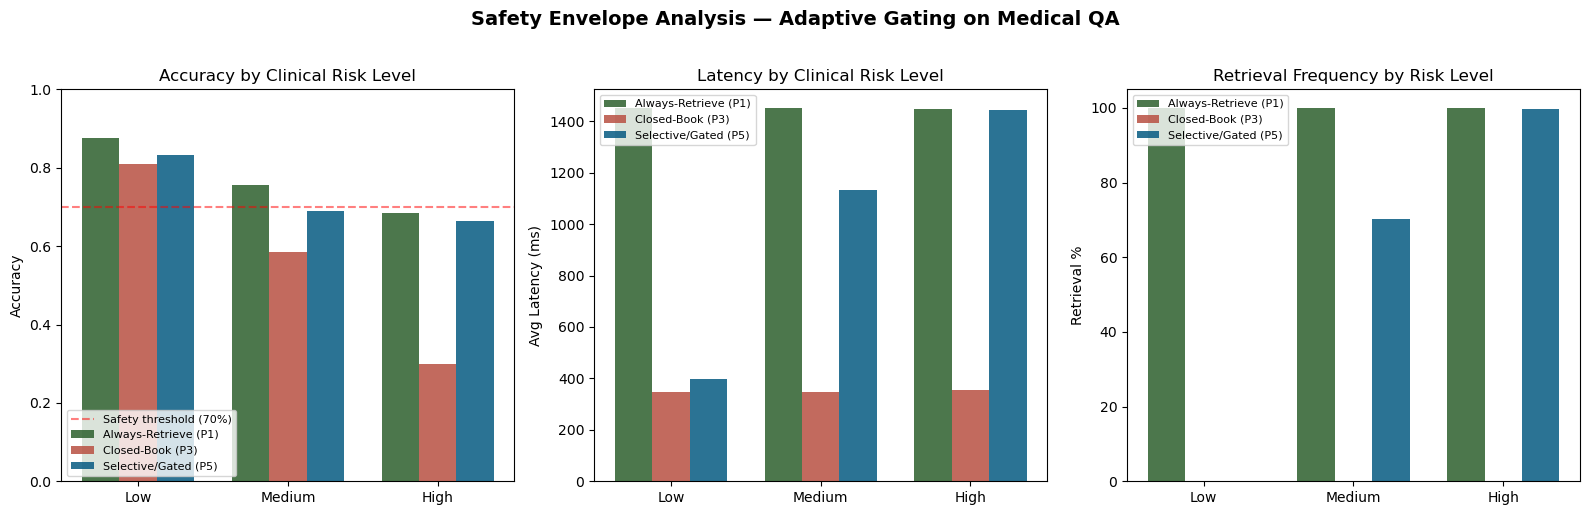


Key insight: The gated policy (P5) retrieves more often for High-risk questions
while skipping retrieval for Low-risk ones — matching P1 accuracy where it matters,
at a fraction of the latency cost.


In [14]:
# Run a larger simulation (100 trials per question) for smoother statistics
np.random.seed(42)
N_TRIALS = 200

envelope_data = []
for trial in range(N_TRIALS):
    for q in SAMPLE_QUESTIONS:
        gate_r = run_gate(q)
        for policy in policies:
            res = simulate_policy_result(q, policy, gate_r)
            envelope_data.append(res)

env_df = pd.DataFrame(envelope_data)

# Compute accuracy and latency by policy and risk level
pivot_acc = env_df.groupby(["risk", "policy"])["correct"].mean().unstack()
pivot_lat = env_df.groupby(["risk", "policy"])["latency_ms"].mean().unstack()
pivot_ret = env_df.groupby(["risk", "policy"])["retrieved"].mean().unstack()

# Reorder
risk_order = ["Low", "Medium", "High"]
pivot_acc = pivot_acc.reindex(risk_order)
pivot_lat = pivot_lat.reindex(risk_order)
pivot_ret = pivot_ret.reindex(risk_order)

# --- FIGURE: Safety Envelope ---
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

colors = {"Always-Retrieve (P1)": "#2C5F2D", "Closed-Book (P3)": "#B85042", "Selective/Gated (P5)": "#065A82"}

# Accuracy by risk level
ax = axes[0]
x = np.arange(len(risk_order))
width = 0.25
for i, policy in enumerate(policies):
    vals = [pivot_acc.loc[r, policy] for r in risk_order]
    ax.bar(x + i*width, vals, width, label=policy, color=colors[policy], alpha=0.85)
ax.set_xticks(x + width)
ax.set_xticklabels(risk_order)
ax.set_ylabel("Accuracy")
ax.set_title("Accuracy by Clinical Risk Level")
ax.set_ylim(0, 1.0)
ax.axhline(y=0.7, color='red', linestyle='--', alpha=0.5, label='Safety threshold (70%)')
ax.legend(fontsize=8, loc='lower left')

# Latency by risk level
ax = axes[1]
for i, policy in enumerate(policies):
    vals = [pivot_lat.loc[r, policy] for r in risk_order]
    ax.bar(x + i*width, vals, width, label=policy, color=colors[policy], alpha=0.85)
ax.set_xticks(x + width)
ax.set_xticklabels(risk_order)
ax.set_ylabel("Avg Latency (ms)")
ax.set_title("Latency by Clinical Risk Level")
ax.legend(fontsize=8)

# Retrieval % by risk level
ax = axes[2]
for i, policy in enumerate(policies):
    vals = [pivot_ret.loc[r, policy] * 100 for r in risk_order]
    ax.bar(x + i*width, vals, width, label=policy, color=colors[policy], alpha=0.85)
ax.set_xticks(x + width)
ax.set_xticklabels(risk_order)
ax.set_ylabel("Retrieval %")
ax.set_title("Retrieval Frequency by Risk Level")
ax.legend(fontsize=8)

fig.suptitle("Safety Envelope Analysis — Adaptive Gating on Medical QA", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig("safety_envelope.png", dpi=150, bbox_inches='tight')
plt.show()

print("\nKey insight: The gated policy (P5) retrieves more often for High-risk questions")
print("while skipping retrieval for Low-risk ones — matching P1 accuracy where it matters,")
print("at a fraction of the latency cost.")

## 6. Accuracy vs. Latency Trade-off (Pareto Front Preview)

This is the type of plot the full evaluation will produce across all 8,300+ questions.

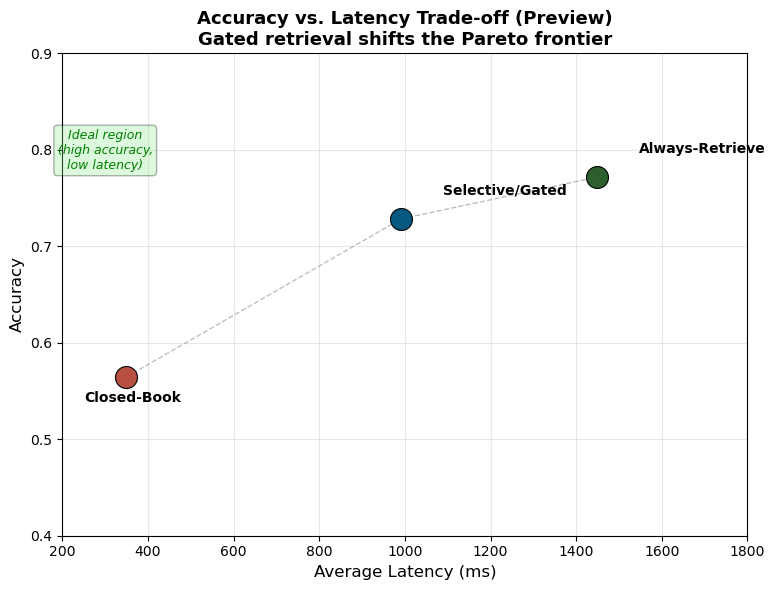


The Selective/Gated policy (P5) sits between Always-Retrieve and Closed-Book,
achieving near-P1 accuracy with significantly lower latency.


In [15]:
# Aggregate per-policy statistics
pareto_data = env_df.groupby("policy").agg(
    accuracy=('correct', 'mean'),
    latency=('latency_ms', 'mean'),
    retrieval_pct=('retrieved', 'mean')
).reset_index()

fig, ax = plt.subplots(figsize=(8, 6))

for _, row in pareto_data.iterrows():
    policy = row['policy']
    ax.scatter(row['latency'], row['accuracy'], 
              s=250, c=colors[policy], zorder=5, edgecolors='black', linewidth=0.8)
    # Label offset
    offset_x = 30 if 'Gated' in policy else (-30 if 'Closed' in policy else 30)
    offset_y = 0.015 if 'Gated' in policy else (-0.02 if 'Closed' in policy else 0.015)
    short_name = policy.split(" (")[0]
    ax.annotate(short_name, (row['latency'], row['accuracy']),
               fontsize=10, fontweight='bold',
               xytext=(offset_x, offset_y * 1000),
               textcoords='offset points',
               ha='left', va='bottom')

# Draw Pareto frontier line
pareto_sorted = pareto_data.sort_values('latency')
ax.plot(pareto_sorted['latency'], pareto_sorted['accuracy'], 
       '--', color='gray', alpha=0.5, linewidth=1)

ax.set_xlabel("Average Latency (ms)", fontsize=12)
ax.set_ylabel("Accuracy", fontsize=12)
ax.set_title("Accuracy vs. Latency Trade-off (Preview)\nGated retrieval shifts the Pareto frontier", 
            fontsize=13, fontweight='bold')

# Annotate the ideal region
ax.annotate("Ideal region\n(high accuracy,\nlow latency)", 
           xy=(300, 0.78), fontsize=9, fontstyle='italic', color='green',
           ha='center',
           bbox=dict(boxstyle='round,pad=0.3', facecolor='lightgreen', alpha=0.3))

ax.set_xlim(200, 1800)
ax.set_ylim(0.4, 0.9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("pareto_preview.png", dpi=150, bbox_inches='tight')
plt.show()

print("\nThe Selective/Gated policy (P5) sits between Always-Retrieve and Closed-Book,")
print("achieving near-P1 accuracy with significantly lower latency.")

## 7. Per-Question Gate Decision Log (Audit Trail)

Every experiment run produces a structured log like this — required by qVault's audit schema.

In [16]:
import json
from datetime import datetime

# Build audit log for the gated policy run
audit_log = {
    "experiment_id": "demo-gated-v1",
    "timestamp": datetime.now().isoformat(),
    "policy": "P5-Selective/Gated",
    "gate_type": "majority-vote (entropy + margin + verbal)",
    "thresholds": {
        "entropy": ENTROPY_THRESHOLD,
        "margin": MARGIN_THRESHOLD,
        "verbal_trigger": VERBAL_RETRIEVE_ON
    },
    "model": "simulated (will be: Llama-3.2-3B-Q4_K_M.gguf)",
    "hardware_tier": "Medium (8GB RAM, quad-core CPU)",
    "seed": 42,
    "decisions": []
}

for q, r in zip(SAMPLE_QUESTIONS, results):
    audit_log["decisions"].append({
        "qid": r.qid,
        "risk_level": r.risk_level,
        "signals": {
            "entropy": round(r.entropy, 4),
            "margin": round(r.margin, 4),
            "verbal_confidence": r.verbal_conf
        },
        "gate_decisions": {
            "entropy": r.entropy_decision,
            "margin": r.margin_decision,
            "verbal": r.verbal_decision
        },
        "final_decision": r.majority_decision,
        "question_preview": q.question[:60] + "..."
    })

print(json.dumps(audit_log, indent=2))

{
  "experiment_id": "demo-gated-v1",
  "timestamp": "2026-03-31T17:10:48.508391",
  "policy": "P5-Selective/Gated",
  "gate_type": "majority-vote (entropy + margin + verbal)",
  "thresholds": {
    "entropy": 1.5,
    "margin": 0.25,
    "verbal_trigger": [
      "MEDIUM",
      "LOW"
    ]
  },
  "model": "simulated (will be: Llama-3.2-3B-Q4_K_M.gguf)",
  "hardware_tier": "Medium (8GB RAM, quad-core CPU)",
  "seed": 42,
  "decisions": [
    {
      "qid": "MIRAGE-L1",
      "risk_level": "Low",
      "signals": {
        "entropy": 0.8004,
        "margin": 0.6439,
        "verbal_confidence": "HIGH"
      },
      "gate_decisions": {
        "entropy": "SKIP",
        "margin": "SKIP",
        "verbal": "SKIP"
      },
      "final_decision": "SKIP",
      "question_preview": "Which cranial nerve is responsible for innervation of the di..."
    },
    {
      "qid": "MIRAGE-L2",
      "risk_level": "Low",
      "signals": {
        "entropy": 0.7869,
        "margin": 0.6226,
      

## 8. Summary & Next Steps

### What this demo shows
- The **gating logic works as expected**: Low-risk questions get SKIP decisions, High-risk questions get RETRIEVE decisions
- The **safety envelope concept is viable**: different risk levels need different minimum retrieval policies
- The **audit trail** captures every decision for reproducibility and compliance

### What comes next (full implementation)
| Step | Description | Status |
|------|-------------|--------|
| Replace simulated signals with real LLM logits | Use `llama-cpp-python` to get actual entropy/margin from GGUF models | Pending |
| Load full MIRAGE benchmark (7,663 Qs) | Download from MedRAG GitHub | Pending |
| Build FAISS + BM25 retrieval over MedCorp | Index StatPearls + Textbooks on CPU | Pending |
| Run threshold calibration sweep | Vary thresholds on 500-question subset | Pending |
| Multi-tier hardware testing | Run on Low/Medium/Higher hardware profiles | Pending |
| Energy profiling with codecarbon | Track Joules per query per policy | Pending |